In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, utils

# Charge MNIST: 60 000 images d'entraînement, 10 000 de test
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


In [14]:
# Reshape pour canal unique et normalisation [0,255]→[0,1]
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encoding des Labels
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

print("Après prétraitement : ", x_train.shape, y_train.shape)

Après prétraitement :  (60000, 28, 28, 1) (60000, 10)


In [16]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(16, kernel_size=(5, 5), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    # 5x5x16  vecteur de taille 400
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Affiche l'architecture et le nombre de paramètres
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

Epoch 1/5
422/422 - 23s - 54ms/step - accuracy: 0.9045 - loss: 0.3346 - val_accuracy: 0.9713 - val_loss: 0.0954
Epoch 2/5
422/422 - 19s - 44ms/step - accuracy: 0.9706 - loss: 0.0947 - val_accuracy: 0.9792 - val_loss: 0.0671
Epoch 3/5
422/422 - 22s - 51ms/step - accuracy: 0.9789 - loss: 0.0684 - val_accuracy: 0.9822 - val_loss: 0.0593
Epoch 4/5
422/422 - 20s - 47ms/step - accuracy: 0.9831 - loss: 0.0544 - val_accuracy: 0.9855 - val_loss: 0.0534
Epoch 5/5
422/422 - 21s - 49ms/step - accuracy: 0.9857 - loss: 0.0451 - val_accuracy: 0.9867 - val_loss: 0.0489


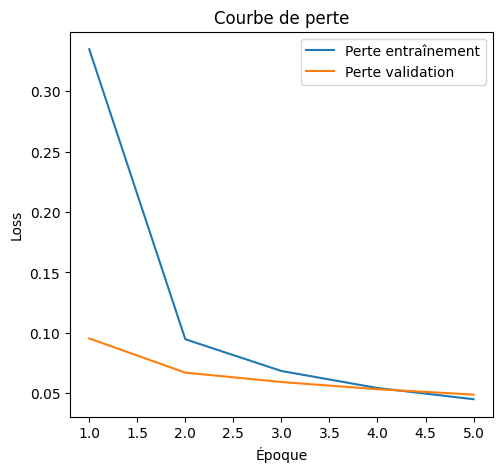

In [19]:
# Tracé des courbes
import matplotlib.pyplot as plt

# Nombre d'époques
epochs = range(1, len(history.history['loss']) + 1)

# Perte
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'],
         label='Perte entraînement')
plt.plot(epochs, history.history['val_loss'], label='Perte validation')
plt.title('Courbe de perte')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()

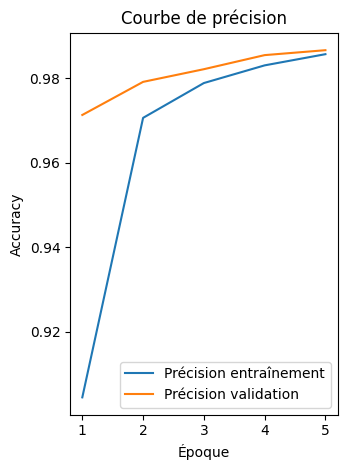

In [20]:
# Précision
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['accuracy'], label='Précision entraînement')
plt.plot(epochs, history.history['val_accuracy'], label='Précision validation')
plt.title('Courbe de précision')
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=9)
print(f"Précision sur test : {test_acc*100:.2f}%")

Précision sur test : 98.67%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


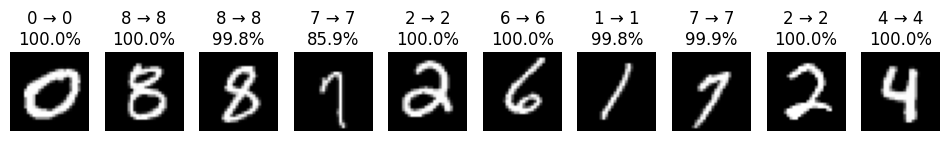

In [23]:
# 10 exemples aléatoires
indices        = np.random.choice(len(x_test), 10, replace=False)
x_sample       = x_test[indices]
y_true         = np.argmax(y_test[indices], axis=1)

# Prédictions : vecteurs de probas (softmax)
y_probs        = model.predict(x_sample)          # shape (10,10)
y_pred         = np.argmax(y_probs, axis=1)       # label prédit
confidences    = np.max(y_probs, axis=1)          # probabilité max par échantillon

plt.figure(figsize=(12,3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_sample[i].reshape(28,28), cmap='gray')
    pct = confidences[i] * 100
    plt.title(f"{y_true[i]} → {y_pred[i]}\n{pct:.1f}%")
    plt.axis('off')
plt.show()